<a href="https://colab.research.google.com/github/NickLarsonUVA/DS3001-programming/blob/main/05_assignment_glm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Latent Variable Models (Logistic Regression)

### Foundations of Machine Learning

**Q1.** Please answer the following questions in your own words:

1. Why do we use general linear models/latent variable models/activation functions in analysis? What advantage do they have over linear models?
- Regular linear models don't know when to stop. If you're predicting a probability (like survival), a standard linear model might spit out impossible numbers like -0.2 or 1.5. Latent variable models take the standard linear math (the latent index) and pass it through an activation function. This "squashes" the output so it makes sense for restricting the prediction to be strictly between 0 and 1. The advantage is that you get to keep the explainability of a linear model, but you actually get valid predictions for things like probabilities or categories.
2. Explain why binary and categorical cross entropy are effective loss functions for fitting logistic regression models.
- These loss functions are effective because they heavily penalize the model for being confidently wrong. The further your predicted probability is from the true class label, the bigger the error the model has to "pay" for. Minimizing cross-entropy is the exact same math as maximizing the log-likelihood. So, cross-entropy pushes the model to get its confidence right, not just its predictions
3. True or false, and explain: Logistic regression is a linear model.
- False. Overall, it is a non-linear model because the activation function curves the final output into an S-shape. Even though it is linear deep down (the latent index combines the inputs linearly), passing that index through the activation function makes the final model non-linear.
4. True or false, and explain: Logistic regression cannot be used for classification.
- False. It is completely standard to use it for classification! If you leave the output as a probability (like 0.75), you're doing regression. But if you apply a threshold (like "round anything over 0.5 up to 1"), you are doing hard classification. In Scikit-Learn, this is just the difference between using .predict_proba() versus .predict().
5. Does the coefficient in a logistic regression represent the change in the predicted value for a 1 unit change in the feature/covariate/explanatory variable?
- No, it doesn't. Because the model uses a non-linear S-curve, a 1-unit change in a variable impacts the final probability differently depending on where you currently are on the curve. You can't interpret it as a straight 1-to-1 change like in ordinary linear regression. The safest way to read the coefficient is just the direction where positive means the outcome is more likely, and negative means it's less likely.
6. True or false, and explain: Feature engineering is unnecessary for logistic regression, because it is a nonlinear model.
- False. You definitely still need feature engineering. Even though the activation function makes the final output non-linear, the model still combines the inputs in a linear way to create the latent index. If you just dump raw data into the model, it won't perform well. You still need to build a rich feature space using one-hot encoding, interactions, and powers.
7. True or false, and explain: Logistic regression is an improvement over the usual linear model (ordinary least squares), and you should always use logistic regression instead.
- False. It's not a generic upgrade, it's more just a different tool for a different job. You use standard linear regression when your target variable is a continuous number. You use logistic regression when your target is a discrete category or a binary outcome.

**Q2.** This is a question about student dropout probability.

The relevant data are in `data.csv` and the file is semicolon-separated.

The relevant variables are:
- `Debtor` - `1` if the student has outstanding debt and `0` otherwise
- `Tuition fees up to date` - `1` if tuition is up to date and `0` otherwise
- `Scholarship holder` - `1` if the student has a scholarship and `0` otherwise
- `Age at enrollment` - student's age when entering the program
- `Curricular units 1st sem (approved)` - number of first-semester courses passed
- `Target` - `Dropout`, `Graduate`, or `Enrolled`

1. Load the data, `data.csv`. Be sure to read it with the correct delimiter. Filter on columns to the variables we'll actually use. Document how you handle any missing values. For parts 2-5, create a binary target where `Dropout` corresponds to dropout and `Graduate` or `Enrolled` corresponds to not dropout.

2. Run a logistic regression of dropout status on `Debtor`, `Tuition fees up to date`, `Scholarship holder`, and `Age at enrollment`. Which variables predict a higher dropout probability, and which predict a lower dropout probability? Does being up to date on tuition seem to reduce dropout risk?

3. Use `.predict_proba` and compute expected dropout probabilities. Make a scatter plot of your predicted dropout probability against `Age at enrollment`, hued by `Tuition fees up to date`. For what ages does being up to date on tuition seem to reduce dropout probability the most? On average, by how much does being up to date on tuition change the predicted probability of dropout?

4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?

5. Compute predicted dropout probabilities with a linear model with the same variables, and predict dropout probabilities. Make a histogram of predicted probabilities for both logistic regression and the linear model. Compare their performance.

5. Based on your above work, which students are the most at-risk of dropping out? What kinds of interventions can you imagine that would help at-risk students stay enrolled?

6. Run a multinomial logistic regression of `Target` on `Debtor`, `Tuition fees up to date`, and `Curricular units 1st sem (approved)`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class?


In [14]:
#Q2 - Part 1
import numpy as np
import pandas as pd

df = pd.read_csv('/content/data.csv', sep=';')

# filter columns and drop missing values
vars = [
    'Debtor',
    'Tuition fees up to date',
    'Scholarship holder',
    'Age at enrollment',
    'Curricular units 1st sem (approved)',
    'Target'
]
df = df.loc[:, vars].dropna()

# binary target where Dropout = 1
# matching the One Hot Encoding section using pd.get_dummies
target_dummies = pd.get_dummies(df['Target'], dtype='int')
df['Dropout_binary'] = target_dummies['Dropout']

# check
print(df.head())

   Debtor  Tuition fees up to date  Scholarship holder  Age at enrollment  \
0       0                        1                   0                 20   
1       0                        0                   0                 19   
2       0                        0                   0                 19   
3       0                        1                   0                 20   
4       0                        1                   0                 45   

   Curricular units 1st sem (approved)    Target  Dropout_binary  
0                                    0   Dropout               1  
1                                    6  Graduate               0  
2                                    0   Dropout               1  
3                                    6  Graduate               0  
4                                    5  Graduate               0  


In [15]:
#Q2 - Part 2
from sklearn.linear_model import LogisticRegression

# define features (X) and target (y)
features = [
    'Debtor',
    'Tuition fees up to date',
    'Scholarship holder',
    'Age at enrollment'
]
X = df[features]
y = df['Dropout_binary']

# logistic regression
# using penalty=None to match the class notes for standard logistic regression
log_reg = LogisticRegression(penalty=None, max_iter=1000)
log_reg = log_reg.fit(X, y)

# print the coefficients nicely to answer the questions
coef_df = pd.DataFrame({
    'Variable': log_reg.feature_names_in_,
    'Coefficient': log_reg.coef_[0]
})
print(coef_df)

                  Variable  Coefficient
0                   Debtor     0.527137
1  Tuition fees up to date    -2.605617
2       Scholarship holder    -1.242299
3        Age at enrollment     0.049841


Variables with positive coefficients, like being a debtor and age at enrollment, predict a higher dropout probability, whereas variables with negative coefficients like having a scholarship and being up to date on tuition predict a lower probability. Because being up to date on tuition has a strong negative coefficient, it definitely seems to reduce a student's risk of dropping out.

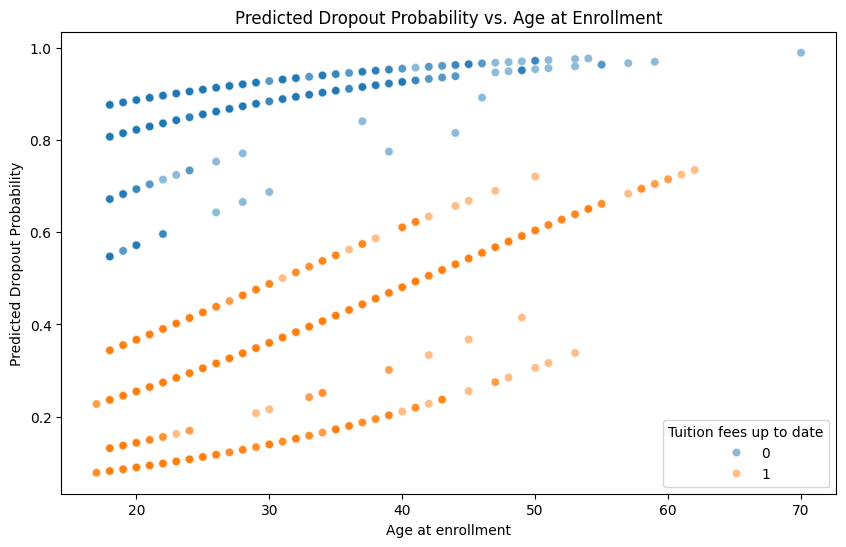

Average predicted probability if tuition is paid: 0.2474
Average predicted probability if tuition is NOT paid: 0.8655
Average change in probability: 0.6181


In [16]:
#Q2 - Part 3
import matplotlib.pyplot as plt
import seaborn as sns

# predicted probabilities
probs = log_reg.predict_proba(X)
# only want the probability of the second class (Dropout = 1)
dropout_probs = [ row[1] for row in probs ] # Life is suffering

# add these probabilities back to our dataframe so we can easily plot them
df['Predicted_Dropout_Prob'] = dropout_probs

# scatter making
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x='Age at enrollment',
    y='Predicted_Dropout_Prob',
    hue='Tuition fees up to date',
    alpha=0.5 # Making dots slightly see-through helps if they overlap
)
plt.title('Predicted Dropout Probability vs. Age at Enrollment')
plt.ylabel('Predicted Dropout Probability')
plt.show()

# average difference to answer the final question
avg_prob_paid = df[df['Tuition fees up to date'] == 1]['Predicted_Dropout_Prob'].mean()
avg_prob_not_paid = df[df['Tuition fees up to date'] == 0]['Predicted_Dropout_Prob'].mean()
avg_diff = avg_prob_not_paid - avg_prob_paid

print(f"Average predicted probability if tuition is paid: {avg_prob_paid:.4f}")
print(f"Average predicted probability if tuition is NOT paid: {avg_prob_not_paid:.4f}")
print(f"Average change in probability: {avg_diff:.4f}")

Looking at the scatter plot, being up to date on tuition reduces the predicted dropout probability significantly across the board, but the effect is most dramatic for younger students. Specifically, the vertical gap between the unpaid (blue) and paid (orange) groups is widest for students in their late teens to late twenties. The calculations confirm this massive impact, showing that the average predicted dropout probability falls from 86.55% when tuition is unpaid to only 24.74% when it is paid. Overall, staying current on tuition fees lowers a student's predicted chance of dropping out by an average of 61.81%.

In [17]:
#Q2 - Part 4
# hard classifications (0 or 1) instead of probabilities
y_class = log_reg.predict(X)

# confusion matrix using pandas crosstab
tab = pd.crosstab(y_class, y)
print("Confusion matrix:\n", tab)

# accuracy by dividing the trace (sum of correct predictions on the diagonal) by total observations
acc = np.trace(tab) / len(y_class)
print(f"\nAccuracy: {acc:.4f}")

Confusion matrix:
 Dropout_binary     0    1
row_0                    
0               2841  891
1                162  530

Accuracy: 0.7620


The accuracy of the logistic regression classifier is .7620, 76.2%

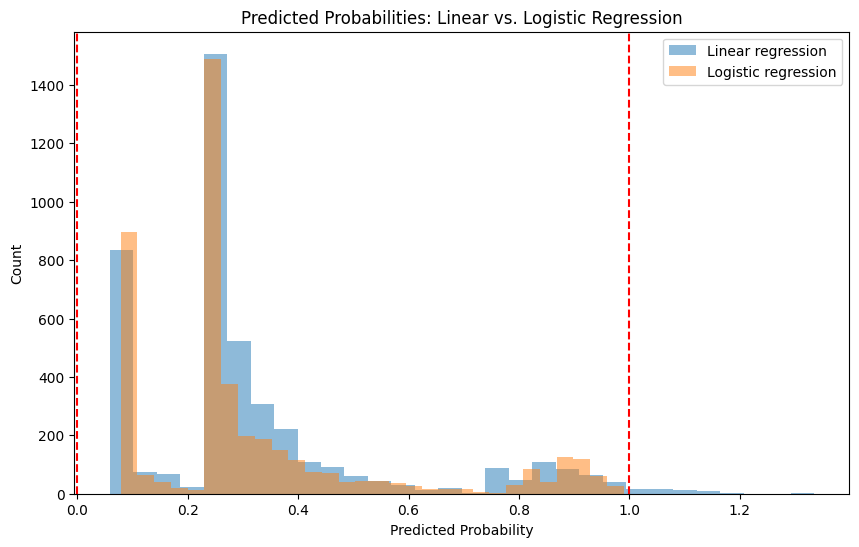

In [18]:
#Q2 - Part 5
from sklearn.linear_model import LinearRegression

# linear model using the exact same features and target
lin_reg = LinearRegression()
lin_reg = lin_reg.fit(X, y)

# get the predicted "probabilities" from the linear model
lin_probs = lin_reg.predict(X)

# histogram
plt.figure(figsize=(10, 6))

# plotting both sets of probabilities (using dropout_probs from the previous step)
plt.hist(x=lin_probs, alpha=0.5, label='Linear regression', bins=30)
plt.hist(x=dropout_probs, alpha=0.5, label='Logistic regression', bins=30)

# adding the red dashed lines at 0 and 1 to show probability bounds
plt.axvline(x=0, color='red', linestyle='--')
plt.axvline(x=1, color='red', linestyle='--')

plt.xlabel('Predicted Probability')
plt.ylabel('Count')
plt.title('Predicted Probabilities: Linear vs. Logistic Regression')
plt.legend()
plt.show()

Based on the histogram, you can see that the linear regression model (the blue bars) predicts values greater than 1 on the far right side. Since a probability can't be more than 100%, those linear model predictions don't actually make any sense for what we are trying to find. On the other hand, the logistic regression model (the orange bars) keeps all of its predictions neatly packed between the 0 and 1 boundaries. Because it doesn't give us those impossible out-of-bounds numbers, the logistic regression model is definitely the better and more reliable tool for this job.

In [19]:
#Q2 - Part 6

Based on the scatter plot and our logistic regression, the students most at risk of dropping out are those in their late teens to late twenties who are behind on tuition, facing a massive average dropout probability of 86.55%. However, when students are up to date on their fees, that risk plummets to just 24.74%, proving that financial struggles are a massive barrier to graduating. To help these at-risk students stay enrolled, the university should implement financial interventions like emergency grants, debt forgiveness, or more flexible, interest-free payment plans. Additionally, creating targeted advising or support groups could help older students better navigate the overwhelming stress of balancing school with financial burdens.

In [20]:
#Q2 - Part 7
# define the new features and use the ORIGINAL multi-class Target
features_multi = ['Debtor', 'Tuition fees up to date', 'Curricular units 1st sem (approved)']
X_multi = df[features_multi]
y_multi = df['Target']

# multinomial Logistic Regression
mnl = LogisticRegression(penalty=None, max_iter=1000)
mnl = mnl.fit(X_multi, y_multi)

#.predict for hard classification and make a confusion matrix
y_pred_hard = mnl.predict(X_multi)
tab_multi = pd.crosstab(y_multi, y_pred_hard)

print("Confusion Matrix (Hard Classification):")
print(tab_multi)

# .predict_proba to see the actual probabilities
probs_multi = pd.DataFrame(mnl.predict_proba(X_multi), columns=mnl.classes_)

print("\nPredicted Probabilities (First 5 rows):")
print(probs_multi.head())

Confusion Matrix (Hard Classification):
col_0     Dropout  Graduate
Target                     
Dropout      1054       367
Enrolled      280       514
Graduate      146      2063

Predicted Probabilities (First 5 rows):
    Dropout  Enrolled  Graduate
0  0.680560  0.210486  0.108954
1  0.706615  0.145494  0.147892
2  0.954343  0.040341  0.005316
3  0.117346  0.176786  0.705867
4  0.183691  0.212551  0.603758


Describing results:
- Looking at the confusion matrix, the model does a solid job of identifying students who drop out (1054 correct) and students who graduate (2063 correct). However, it completely fails with the "Enrolled" group—it misclassified every single enrolled student as either a dropout or a graduate.

Does hard classification predict every class?
- No, it doesn't. If you look at the columns of the confusion matrix, only "Dropout" and "Graduate" show up. The model literally never guessed "Enrolled" as a hard classification for any student.

Dopredicted probabilities predict every class?
- Yes, they do. Even though the hard classification completely ignores the "Enrolled" category, the predicted probabilities table clearly has columns for all three classes (Dropout, Enrolled, Graduate). This shows that the model calculates some probability for every class, even if "Enrolled" never had a high enough probability to be the final hard prediction.

**Q3.** This is a question about 10-year survival rate for cirrhosis of the liver.

The relevant data are:
- `Bilirubin` - A liver byproduct produced when red blood cells break down
- `Edema` - Swelling in limbs; `N` for none, `S` for edema resolvable with diuretics, `Y` for edema despite dirutics
- `Drug` - D-penicillamine, or placebo
- `Stage` - current state of disease, from 1 to 4
- `Status` - `C` or `CL` corresponds to alive, and `D` corresponds to dead

1. Load the data, `cirrhosis.csv`. Filter on columns to the variables we'll actually use. Document how you handle any missing values.

2. Run a logistic regression of `Status` on `Edema`, `Drug`, and `Bilirubin`. Does the drug improve survival probability? Does higher or lower bilirubin predict a higher or lower survival rate? How does survival rate vary with edema?

3. Use `.predict_proba` and compute expected surivival probabilities. Make a scatter plot of your predicted survival probability against `Bilirubin`, hued by `Drug`. For what values of `Bilirubin` does the drug seem to increase patient survival rate? On average, by how much do patients who take the drug increase their probability of survival?

4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?

5. Compute predicted survival probabilities with a linear model with the same variables, and predict survival probabilties. Make a histogram of predictive probabilties for both logistic regression and the linear model. Compare their performance.

6. Run a logistic regression of `Stage` on `Edema` and `Bilirubin`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class?

In [21]:
#Q3 - Part 1
import pandas as pd

# load
df = pd.read_csv('/content/cirrhosis.csv')

# filter to only the columns we need and DROP any missing values
vars = [
    'Status',
    'Edema',
    'Drug',
    'Bilirubin',
    'Stage'
]
df = df.loc[:, vars].dropna() #dropping

# group the Status column and create our binary target
# C and CL both mean the patient is alive
df['Status_Grouped'] = df['Status'].replace({'C': 'Alive', 'CL': 'Alive', 'D': 'Dead'})

# dummy variables and grab the 'Alive' column (1 = Survived, 0 = Dead)
status_dummies = pd.get_dummies(df['Status_Grouped'], dtype='int')
df['Survival_binary'] = status_dummies['Alive']

print(df.head())

  Status Edema             Drug  Bilirubin  Stage Status_Grouped  \
0      D     Y  D-penicillamine       14.5    4.0           Dead   
1      C     N  D-penicillamine        1.1    3.0          Alive   
2      D     S  D-penicillamine        1.4    4.0           Dead   
3      D     S  D-penicillamine        1.8    4.0           Dead   
4     CL     N          Placebo        3.4    3.0          Alive   

   Survival_binary  
0                0  
1                1  
2                0  
3                0  
4                1  


In [22]:
#Q3 - Part 2
from sklearn.linear_model import LogisticRegression

# handle categorical variables (drug and edema) using one-hot encoding
# drop_first=True prevents the dummy variable trap
X_categorical = pd.get_dummies(df[['Edema', 'Drug']], drop_first=True, dtype=int)

# numeric variable (bilirubin)
X_numeric = df[['Bilirubin']]

# combine to make final feature matrix (X) and define target (y)
X = pd.concat([X_numeric, X_categorical], axis=1)
y = df['Survival_binary']

# run the standard Logistic Regression
log_reg3 = LogisticRegression(penalty=None, max_iter=1000)
log_reg3 = log_reg3.fit(X, y)

# print
coef_df = pd.DataFrame({
    'Variable': log_reg3.feature_names_in_,
    'Coefficient': log_reg3.coef_[0]
})
print(coef_df)

       Variable  Coefficient
0     Bilirubin    -0.350381
1       Edema_S    -0.578551
2       Edema_Y    -2.859322
3  Drug_Placebo     0.252657


The drug doesn't improve survival probability. The coefficient for Drug_Placebo is positive (0.2526). Because the baseline that was dropped is the actual drug (D-penicillamine), this positive number means taking the placebo is associated with a higher survival rate than taking the drug. So, the drug does not seem to improve survival.

The coefficient for Bilirubin is negative (-0.3503), which means that higher levels of bilirubin predict a lower survival rate.

Having any form of edema lowers the survival rate, since both coefficients are negative compared to having no edema. However, severe edema (Edema_Y at -2.859) drops the survival rate way more drastically than mild, resolvable edema (Edema_S at -0.578).

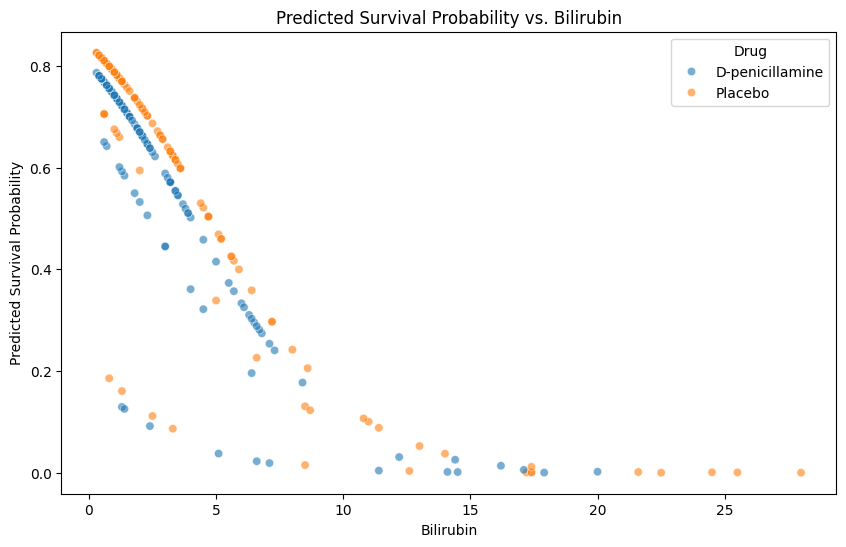

Average survival probability (D-penicillamine): 0.5886
Average survival probability (Placebo): 0.6104
Average change in probability from the drug: -0.0218


In [23]:
#Q3 - Part 3
import matplotlib.pyplot as plt
import seaborn as sns

# predicted probabilities for survival
probs = log_reg3.predict_proba(X)
# survival is class '1' from above
df['Predicted_Survival_Prob'] = [row[1] for row in probs] # Life is suffering

# scatter
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x='Bilirubin',
    y='Predicted_Survival_Prob',
    hue='Drug',
    alpha=0.6
)
plt.title('Predicted Survival Probability vs. Bilirubin')
plt.ylabel('Predicted Survival Probability')
plt.show()

# average difference to answer the final question
avg_prob_drug = df[df['Drug'] == 'D-penicillamine']['Predicted_Survival_Prob'].mean()
avg_prob_placebo = df[df['Drug'] == 'Placebo']['Predicted_Survival_Prob'].mean()
avg_diff = avg_prob_drug - avg_prob_placebo

print(f"Average survival probability (D-penicillamine): {avg_prob_drug:.4f}")
print(f"Average survival probability (Placebo): {avg_prob_placebo:.4f}")
print(f"Average change in probability from the drug: {avg_diff:.4f}")

Looking at the scatter plot, the orange placebo dots are consistently higher than the blue drug dots across the entire graph. This tells us that there are actually no values of bilirubin where the drug increases the patient's survival rate. The calculations confirm this negative effect, showing that the drug does the exact opposite of what we'd hope. On average, patients who take D-penicillamine actually see their predicted probability of survival drop by about 2.18% compared to those just taking the placebo.

In [24]:
#Q3 - Part 4
#get the hard classifications (0 or 1) instead of probabilities
y_class = log_reg3.predict(X)

# compute the confusion matrix
tab = pd.crosstab(y_class, y)
print("Confusion Matrix:\n", tab)

# calculate accuracy by dividing the trace by total observations
acc = np.trace(tab) / len(y_class)
print(f"\nAccuracy: {acc:.4f}")

Confusion Matrix:
 Survival_binary   0    1
row_0                   
0                57   14
1                68  173

Accuracy: 0.7372


The accuracy is .7372, 73.72%

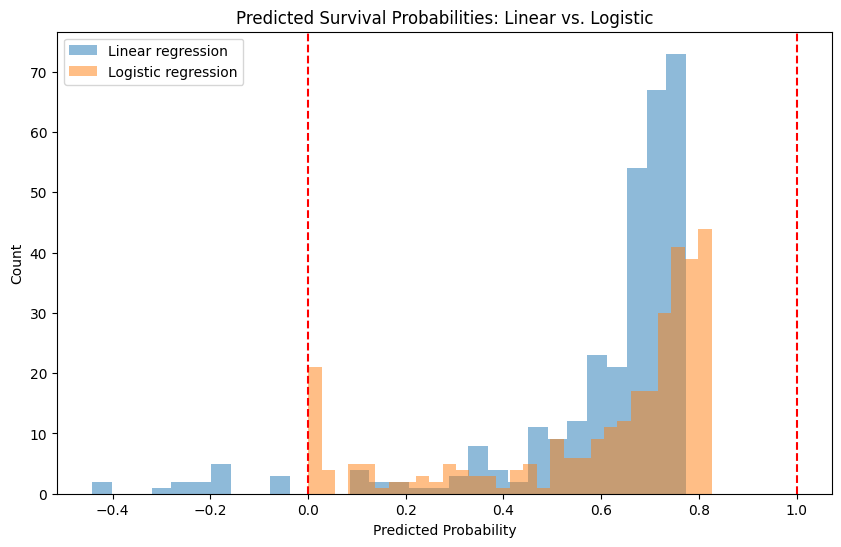

In [25]:
#Q3 - Part 5
# fit the linear model using the exact same features and target
lin_reg = LinearRegression()
lin_reg = lin_reg.fit(X, y)

# predicted "probabilities" from the linear model
lin_probs = lin_reg.predict(X)

# overlapping histogram
plt.figure(figsize=(10, 6))

# plotting both sets of probabilities
# using the column we created in Part 3 for the logistic probabilities
plt.hist(x=lin_probs, alpha=0.5, label='Linear regression', bins=30)
plt.hist(x=df['Predicted_Survival_Prob'], alpha=0.5, label='Logistic regression', bins=30)

# red dashed lines at 0 and 1 to show probability bounds
plt.axvline(x=0, color='red', linestyle='--')
plt.axvline(x=1, color='red', linestyle='--')

plt.xlabel('Predicted Probability')
plt.ylabel('Count')
plt.title('Predicted Survival Probabilities: Linear vs. Logistic')
plt.legend()
plt.show()

Based on the histogram, you can clearly see that the linear regression model (the blue bars) predicts negative survival probabilities that fall well below 0 on the left side of the graph. Since a person's chance of survival can't be less than 0%, these linear model predictions don't make any mathematical sense. On the other hand, the logistic regression model (the orange bars) keeps all of its predictions neatly within the 0 to 1 boundaries. Because the linear model generates these impossible, out-of-bounds numbers, the logistic regression model is clearly the more reliable and accurate tool for predicting patient survival.

In [26]:
#Q3 - Part 6
# define new features and target
# use the get_dummies just for Edema, and combine it with Bilirubin
X_edema = pd.get_dummies(df[['Edema']], drop_first=True, dtype=int)
X_stage = pd.concat([df[['Bilirubin']], X_edema], axis=1)
y_stage = df['Stage']

# logistic regression
log_reg3_stage = LogisticRegression(penalty=None, max_iter=1000)
log_reg3_stage = log_reg3_stage.fit(X_stage, y_stage)

# .predict for hard classification and make a confusion matrix
y_pred_stage = log_reg3_stage.predict(X_stage)
tab_stage = pd.crosstab(y_stage, y_pred_stage)

print("Confusion Matrix (Hard Classification):")
print(tab_stage)

# .predict_proba to see the actual probabilities
probs_stage = pd.DataFrame(log_reg3_stage.predict_proba(X_stage), columns=log_reg3_stage.classes_)

print("\nPredicted Probabilities (First 5 rows):")
print(probs_stage.head())

Confusion Matrix (Hard Classification):
col_0  3.0  4.0
Stage          
1.0     16    0
2.0     61    6
3.0    102   18
4.0     74   35

Predicted Probabilities (First 5 rows):
            1.0       2.0       3.0       4.0
0  2.965432e-08  0.022548  0.124085  0.853367
1  7.611339e-02  0.252747  0.397286  0.273854
2  2.405392e-07  0.175629  0.404098  0.420273
3  1.887830e-07  0.170141  0.403070  0.426790
4  2.053819e-02  0.228845  0.425472  0.325145


The confusion matrix shows that the model actually struggles quite a bit, especially with the early stages of the disease. It completely fails to categorize anyone into Stage 1 or Stage 2, instead just guessing Stage 3 or 4 for every single patient. Because of this, the hard classification definitely does not predict every class. If you look at the column headers, 1.0 and 2.0 are completely missing. However, the predicted probabilities do predict every class. Even though the early stages never have a high enough percentage to "win" the final hard prediction, the second table clearly shows four separate columns, proving the model still calculates a mathematical probability for all four stages.

**Q4.** What are the coefficients of a logistic regression? How do you interpret their values?

1. For your linear model, your predictions are:
$$
\hat{y} = b \cdot x = b_0 + \sum_{k=1}^K b_k x_{k}
$$
What is the derivative of the prediction with respect to the $k$-th feature? For a 1 unit change in your feature, by how much does the prediction change?

2. For the logistic model, your predictions are:
$$
\hat{p}_i = \dfrac{e^{b \cdot x}}{1+e^{b \cdot x}}
$$
What is the derivative of the prediction with respect to the $k$-th feature? As $x$ changes, does your answer change? How is it similar or different from your answer for part 1? Hint: It turns out that
$$
\frac{ \partial }{ \partial L} \dfrac{e^{L}}{1+e^{L}}= \frac{e^{L}}{(1+e^{L})^2} = \frac{e^{L}}{1+e^{L}}\frac{1}{1+e^{L}} = \frac{e^{L}}{1+e^{L}} \left( 1 - \frac{e^{L}}{1+e^{L}} \right),
$$
and use the chain rule( $D_x f(g(x)) = f'(g(x))g'(x)$). For what values of $\hat{p}$ is the coefficient itself (...times 4) roughly a good estimate of how a change in $x_k$ affects the prediction?

3. Alternatively, we can transform the prediction like this:

\begin{alignat*}{2}
\hat{p} &=& \frac{ e^{b \cdot x} }{1+e^{b \cdot x}} \\
\hat{p}(1+e^{b \cdot x}) &=& e^{b \cdot x} \\
\hat{p} &=& (1-\hat{p}) e^{b \cdot x} \\
\log \left( \frac{\hat{p}}{1-\hat{p}} \right) &=& b \cdot x \\
\end{alignat*}

The left-hand side of the above expression is called the **log odds ratio**, and the right-hand side is the latent variable. How does a one unit change in $x_k$ affect the log odds ratio?

Q4 - part 1
-
Because the relationship is purely linear, taking the partial derivative of $\hat{y}$ with respect to a specific feature $x_k$ isolates the coefficient for that feature:$$\frac{\partial \hat{y}}{\partial x_k} = b_k$$

In a logistic regression, the derivative of the prediction with respect to a feature is its coefficient scaled by the variance of the current prediction, calculated as $\hat{p}(1-\hat{p}) \cdot b_k$. Because of this, a one-unit increase in the feature changes the predicted probability by an amount that varies depending on where you currently are on the model's S-shaped curve. The impact is largest right in the middle (at a 50% probability), where a one-unit change in the feature will shift your prediction by a maximum of roughly the coefficient divided by four.

Q4 - part 2
-
Final derivative in image below

As $x$ changes, does your answer change?
- Yes. Because $\hat{p}_i$ is calculated using the $x$ values, any change in $x$ changes the value of $\hat{p}_i$. Since $\hat{p}_i$ is in our final derivative formula, the rate of change itself fluctuates depending on where you are on the curve.

How is it similar or different from your answer for part 1?
- Different: In Part 1 for the linear regression, the rate of change was just a constant number ($b_k$). No matter what $x$ was, the slope was the same. Now the rate of change is dynamic.
- Similar: In both models, the coefficient $b_k$ dictates the direction and baseline scale of the change. If $b_k$ is positive, the prediction goes up and if negative, it goes down.

For what values of $\hat{p}$ is the coefficient itself divided by 4 roughly a good estimate?
- This happens when $\hat{p} = 0.5$. If you look at the variance part of the derivative $\hat{p}_i(1 - \hat{p}_i)$ and plug in $0.5$, you get 1/4
- So, right at the 50% probability mark, the formula simplifies to $\frac{1}{4} \cdot b_k$, meaning a 1-unit change in your feature changes the prediction by exactly $b_k / 4$.

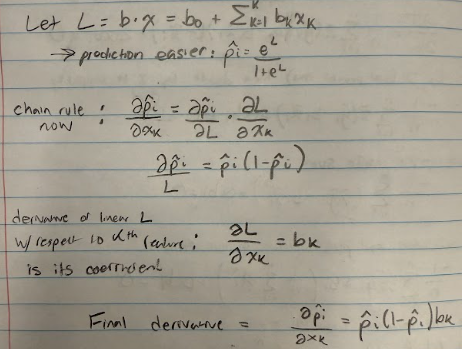

Q4 - Part 3
-
Because the log odds ratio is simply equal to the linear combination of your features ($b_0 + \sum b_k x_k$), the relationship becomes purely linear again. Therefore, a one-unit change in $x_k$ changes the log odds ratio by exactly $b_k$. Unlike the predicted probability in Part 2, this change is constant. It doesn't matter what your starting values are as a one-unit increase in the feature will always shift the log odds by that exact coefficient.